In [1]:
import pandas as pd
import os

# 1. Configuration
input_file = 'Weather Data (US).csv' 
output_file = 'mid_atlantic_weather.csv'

# IDs for NYC, NJ, CT, and PA
target_ids = [
    'USW00094728', 'USW00094789', # NYC
    'USW00014734',                # Newark, NJ
    'USW00014752',                # Bridgeport, CT
    'USW00013739',                # Philly, PA
    'USW00014737',                # Allentown, PA
    'USW00014777',                # Scranton, PA
    'USC00368596'                 # E. Stroudsburg, PA
]

# 2. The Extraction Process
if os.path.exists(input_file):
    print("Large dataset found. Starting extraction (this will take 3-5 minutes)...")
    chunks = []
    # chunksize=100000 ensures we only load a small part of the 8GB at a time
    for chunk in pd.read_csv(input_file, chunksize=100000):
        filtered = chunk[chunk['ID'].isin(target_ids)]
        chunks.append(filtered)
    
    # Save the small version
    final_df = pd.concat(chunks)
    final_df.to_csv(output_file, index=False)
    print(f"Success! {output_file} created with {len(final_df)} rows.")
else:
    print(f"CRITICAL ERROR: Could not find '{input_file}'.")
    print("Check your folder and ensure the name matches perfectly!")

Large dataset found. Starting extraction (this will take 3-5 minutes)...
Success! mid_atlantic_weather.csv created with 84004 rows.


Average Error: 0.65°C


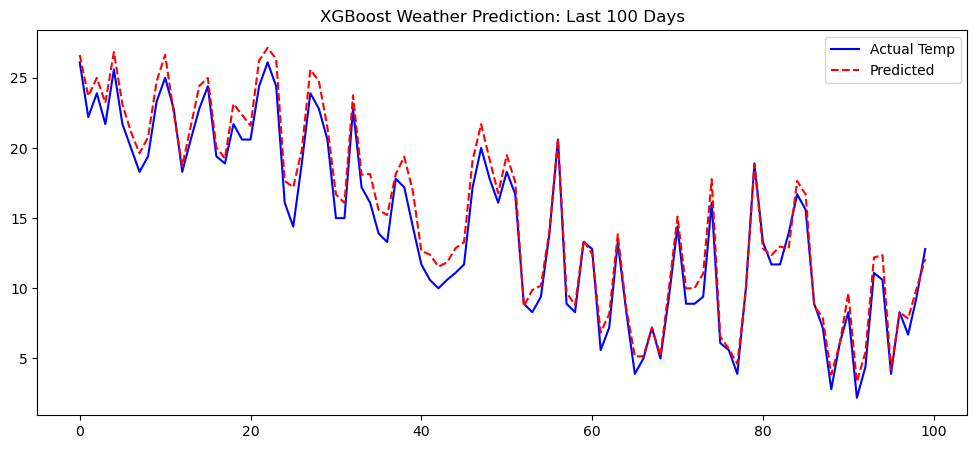

In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# --- A. Data Loading & Cleaning ---
df = pd.read_csv('mid_atlantic_weather.csv')
df['DATE'] = pd.to_datetime(df['DATE'])

# Units are in tenths (e.g., 255 = 25.5°C). Let's fix that:
for col in ['TMAX', 'TMIN', 'PRCP']:
    if col in df.columns:
        df[col] = df[col] / 10

# --- B. Feature Engineering (Pivoting and Lagging) ---
# We want cities as columns to see how weather moves between them
df_pivot = df.pivot(index='DATE', columns='ID', values='TMAX')

# Create Lags: "Yesterday's temp in each city"
for city_id in df_pivot.columns:
    df_pivot[f'{city_id}_lag1'] = df_pivot[city_id].shift(1)

# Add Seasonality (Cyclical Month Encoding)
df_pivot['month_sin'] = np.sin(2 * np.pi * df_pivot.index.month / 12)
df_pivot['month_cos'] = np.cos(2 * np.pi * df_pivot.index.month / 12)

df_ml = df_pivot.dropna()

# --- C. Model Training ---
# Predicting NYC Central Park (USW00094728)
y = df_ml['USW00094728']
X = df_ml.drop(columns=['USW00094728']) # Use everything else to predict it

# Split (Shuffling=False because weather is a time series!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1)
model.fit(X_train, y_train)

# --- D. Results ---
preds = model.predict(X_test)
print(f"Average Error: {mean_absolute_error(y_test, preds):.2f}°C")

plt.figure(figsize=(12, 5))
plt.plot(y_test.values[-100:], label='Actual Temp', color='blue')
plt.plot(preds[-100:], label='Predicted', color='red', linestyle='--')
plt.title("XGBoost Weather Prediction: Last 100 Days")
plt.legend()
plt.show()

--- mid_atlantic_weather.csv already exists. Skipping extraction. ---

--- Model Results ---
Average Prediction Error: 1.16°F


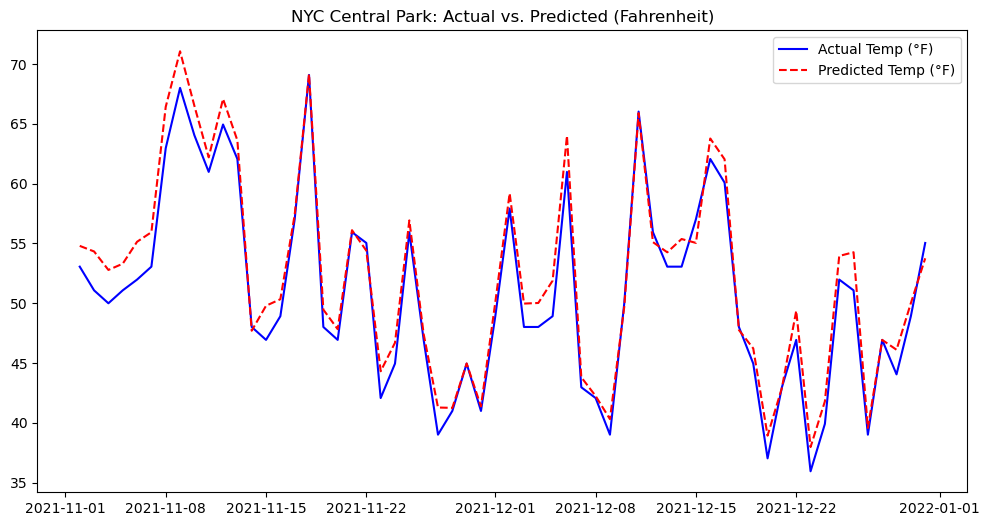

In [3]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# IDs for NYC, NJ, CT, and PA hubs
TARGET_IDS = [
    'USW00094728', 'USW00094789', # NYC (Central Park & JFK)
    'USW00014734',                # Newark, NJ
    'USW00014752',                # Bridgeport, CT
    'USW00013739',                # Philadelphia, PA
    'USW00014737',                # Allentown, PA
    'USW00014777',                # Scranton, PA
    'USC00368596'                 # East Stroudsburg, PA
]

def extract_regional_data():
    if not os.path.exists(PROCESSED_FILE):
        print(f"--- Extracting regional data from {INPUT_FILE} ---")
        chunks = []
        for chunk in pd.read_csv(INPUT_FILE, chunksize=100000):
            filtered = chunk[chunk['ID'].isin(TARGET_IDS)]
            chunks.append(filtered)
        
        final_df = pd.concat(chunks)
        final_df.to_csv(PROCESSED_FILE, index=False)
        print(f"--- Extraction Complete! Saved to {PROCESSED_FILE} ---")
    else:
        print(f"--- {PROCESSED_FILE} already exists. Skipping extraction. ---")


def load_and_clean_data():
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Convert tenths of Celsius to Fahrenheit
    for col in ['TMAX', 'TMIN']:
        if col in df.columns:
            df[col] = ( (df[col] / 10) * 1.8 ) + 32
            
    # Standardize Precipitation (tenths of mm to mm)
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'] / 10
        
    return df

def run_weather_model(df):
    # Pivot so each station is a column
    df_pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # Create "Lag Features" (What was the temp yesterday in each city?)
    for city_id in df_pivot.columns:
        df_pivot[f'{city_id}_yesterday'] = df_pivot[city_id].shift(1)
    
    # Add Cyclical Time Features (Helps model understand seasons)
    df_pivot['month_sin'] = np.sin(2 * np.pi * df_pivot.index.month / 12)
    df_pivot['month_cos'] = np.cos(2 * np.pi * df_pivot.index.month / 12)
    
    # Drop rows with NaN values created by shifting
    df_ml = df_pivot.dropna()
    
    # target = NYC Central Park (USW00094728)
    y = df_ml['USW00094728']
    X = df_ml.drop(columns=['USW00094728'])
    
    # Split data (Shuffling=False for Time Series)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Initialize and Train XGBoost
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
    model.fit(X_train, y_train)
    
    # Evaluate
    predictions = model.predict(X_test)
    error = mean_absolute_error(y_test, predictions)
    print(f"\n--- Model Results ---")
    print(f"Average Prediction Error: {error:.2f}°F")
    
    return y_test, predictions

if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        extract_regional_data()
        weather_df = load_and_clean_data()
        y_test, y_pred = run_weather_model(weather_df)
        
        # Simple plot of the last 60 days
        plt.figure(figsize=(12, 6))
        plt.plot(y_test.index[-60:], y_test.values[-60:], label='Actual Temp (°F)', color='blue')
        plt.plot(y_test.index[-60:], y_pred[-60:], label='Predicted Temp (°F)', color='red', linestyle='--')
        plt.title("NYC Central Park: Actual vs. Predicted (Fahrenheit)")
        plt.legend()
        plt.show()
    else:
        print(f"Error: Please place '{INPUT_FILE}' in this folder.")

--- mid_atlantic_weather.csv found. Using existing file. ---

--- MODEL RESULTS ---
Average Error: 1.13°F
Model R2 Score: 0.9931


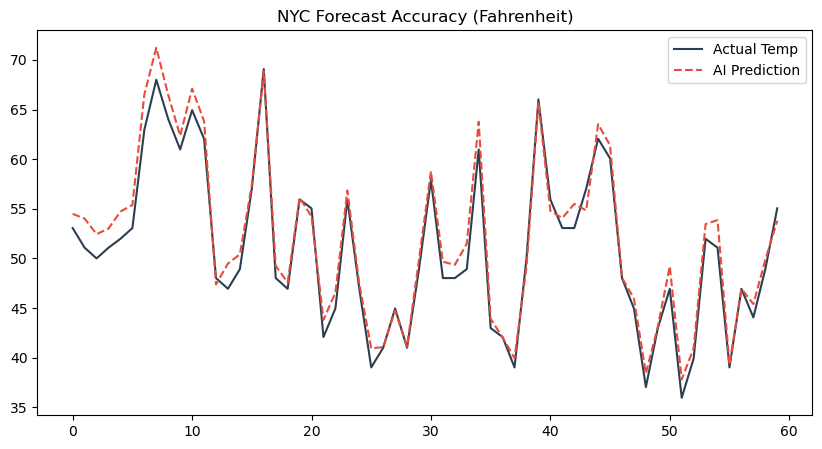

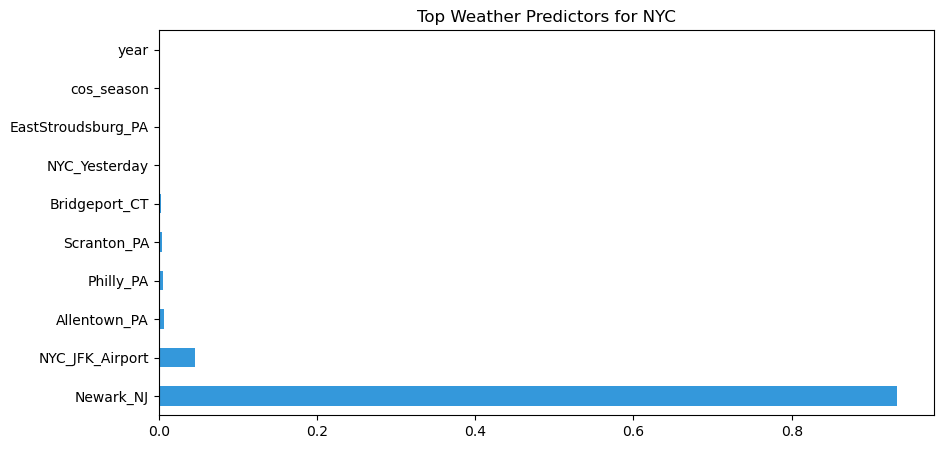

In [14]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# STATION_MAP: This translates ID numbers to names we can read.
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def extract_data():
    """Extracts target stations from the giant 8GB file."""
    if not os.path.exists(PROCESSED_FILE):
        print("--- Scanning giant 8GB file. This takes 3-5 minutes... ---")
        chunks = []
        # Use chunksize to keep your computer from freezing
        for chunk in pd.read_csv(INPUT_FILE, chunksize=100000):
            filtered = chunk[chunk['ID'].isin(STATION_MAP.keys())]
            chunks.append(filtered)
        
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
        print(f"--- Success! Created {PROCESSED_FILE} ---")
    else:
        print(f"--- {PROCESSED_FILE} found. Using existing file. ---")


def load_and_clean():
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Tenths of Celsius -> Standard Fahrenheit
    for col in ['TMAX', 'TMIN']:
        if col in df.columns:
            df[col] = ((df[col] / 10) * 1.8) + 32
    return df


def engineer_features(df):
    # Pivot so each station has its own column
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # SAFETY Rename columns. If ID isn't in map, keep ID name.
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # use PA weather to predict NYC weather
    pivot['Philly_Yesterday'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    
    # Local Memory
    pivot['NYC_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    
    # Seasonal Cycles (Sine/Cosine)
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    # Yearly trend
    pivot['year'] = pivot.index.year
    
    return pivot.dropna()


def run_experiment(data):
    # Target: NYC Central Park | Features: The surrounding region
    y = data['NYC_CentralPark']
    X = data.drop(columns=['NYC_CentralPark'])
    
    # Split: Train on 80%, Test on 20% (shuffle=False for time series)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Train XGBoost model
    model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    print(f"\n--- MODEL RESULTS ---")
    print(f"Average Error: {mean_absolute_error(y_test, preds):.2f}°F")
    print(f"Model R2 Score: {r2_score(y_test, preds):.4f}")
    
    return X, y_test, preds, model

if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        extract_data()
        clean_df = load_and_clean()
        final_data = engineer_features(clean_df)
        X_features, actuals, guesses, my_model = run_experiment(final_data)
        
        # Plotting results
        plt.figure(figsize=(10, 5))
        plt.plot(actuals.tail(60).values, label="Actual Temp", color='#2c3e50')
        plt.plot(guesses[-60:], label="AI Prediction", color='#e74c3c', linestyle='--')
        plt.title("NYC Forecast Accuracy (Fahrenheit)")
        plt.legend()
        plt.show()

        # Plotting Importance
        plt.figure(figsize=(10, 5))
        importances = pd.Series(my_model.feature_importances_, index=X_features.columns)
        importances.nlargest(10).plot(kind='barh', color='#3498db')
        plt.title("Top Weather Predictors for NYC")
        plt.show()
    else:
        print(f"Ensure '{INPUT_FILE}' is in this folder.")


--- RAIN MODEL RESULTS ---
Average Error: 1.39 mm
Model R2 Score: 0.7972


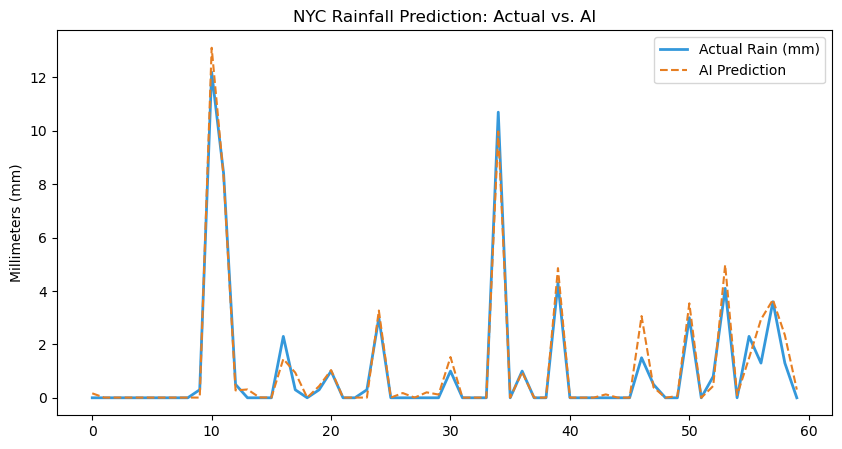

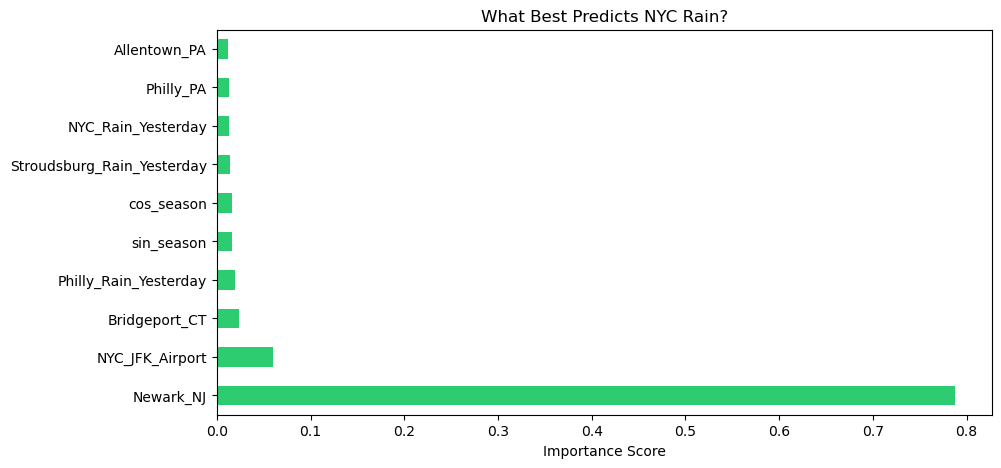

In [24]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def extract_data():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Scanning giant 8GB file... ---")
        chunks = []
        for chunk in pd.read_csv(INPUT_FILE, chunksize=100000):
            filtered = chunk[chunk['ID'].isin(STATION_MAP.keys())]
            chunks.append(filtered)
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    else:
        print(f"--- {PROCESSED_FILE} found. ---")

def load_and_clean():
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Tenths of mm -> mm (Standard Metric for rain)
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'].fillna(0) / 10 
    return df

def engineer_features(df):
    # CHANGE 1: Pivot on PRCP (Rainfall) instead of TMAX
    pivot = df.pivot(index='DATE', columns='ID', values='PRCP')
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # CHANGE 2: Create Rain Lags
    # "Did it rain in PA yesterday?"
    pivot['Philly_Rain_Yesterday'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Rain_Yesterday'] = pivot['Allentown_PA'].shift(1)
    pivot['Stroudsburg_Rain_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    
    # Did it rain in NYC yesterday? (Persistence)
    pivot['NYC_Rain_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    
    # Seasonal Cycles
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return pivot.dropna()

def run_experiment(data):
    # Target: NYC Central Park Rainfall
    y = data['NYC_CentralPark']
    X = data.drop(columns=['NYC_CentralPark'])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # XGBRegressor works for rainfall amount (Regression)
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    # Ensure no negative rain predictions
    preds = np.maximum(preds, 0) 

    print(f"\n--- RAIN MODEL RESULTS ---")
    print(f"Average Error: {mean_absolute_error(y_test, preds):.2f} mm")
    print(f"Model R2 Score: {r2_score(y_test, preds):.4f}")
    
    return X, y_test, preds, model

if __name__ == "__main__":
    if os.path.exists(INPUT_FILE) or os.path.exists(PROCESSED_FILE):
        if not os.path.exists(PROCESSED_FILE): extract_data()
        
        clean_df = load_and_clean()
        final_data = engineer_features(clean_df)
        X_features, actuals, guesses, my_model = run_experiment(final_data)
        
        # Plotting results (Last 60 Days)
        plt.figure(figsize=(10, 5))
        plt.plot(actuals.tail(60).values, label="Actual Rain (mm)", color='#3498db', linewidth=2)
        plt.plot(guesses[-60:], label="AI Prediction", color='#e67e22', linestyle='--')
        plt.title("NYC Rainfall Prediction: Actual vs. AI")
        plt.ylabel("Millimeters (mm)")
        plt.legend()
        plt.show()

        # Plotting Importance
        plt.figure(figsize=(10, 5))
        importances = pd.Series(my_model.feature_importances_, index=X_features.columns)
        importances.nlargest(10).plot(kind='barh', color='#2ecc71')
        plt.title("What Best Predicts NYC Rain?")
        plt.xlabel("Importance Score")
        plt.show()

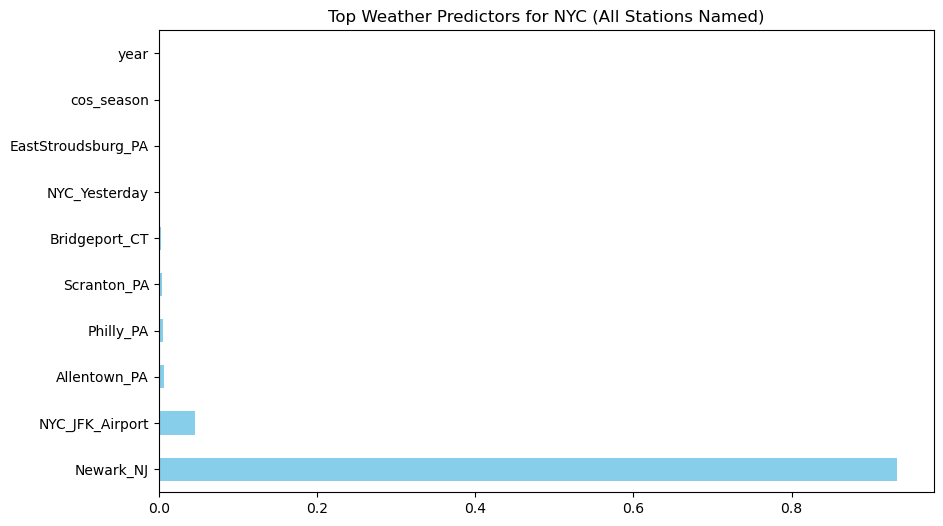

In [5]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def extract_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data (3-5 mins)... ---")
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col] / 10) * 1.8) + 32
    return df

def engineer_features(df):
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # Lag Features (The Memory)
    pivot['NYC_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    pivot['Philly_Yesterday'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    
    # Time/Season Features
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    pivot['year'] = pivot.index.year
    
    return pivot.dropna()


if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        raw_df = extract_and_clean()
        data = engineer_features(raw_df)
        
        y = data['NYC_CentralPark']
        X = data.drop(columns=['NYC_CentralPark'])
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5)
        model.fit(X_train, y_train)
        
        # Plot Feature Importance
        plt.figure(figsize=(10, 6))
        pd.Series(model.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh', color='skyblue')
        plt.title("Top Weather Predictors for NYC (All Stations Named)")
        plt.show()
    else:
        print("Missing 'Weather Data (US).csv'")


   ERROR COMPARISON REPORT
[With Newark]
  - Avg Error (MAE): 1.13°F
  - Accuracy (R2):   0.9931
------------------------------
[Without Newark]
  - Avg Error (MAE): 1.32°F
  - Accuracy (R2):   0.9894
------------------------------


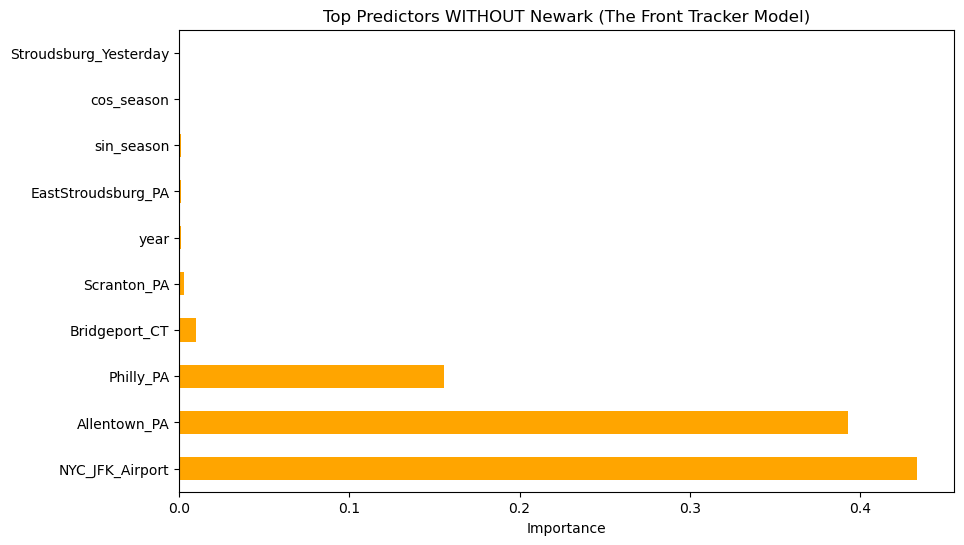

In [6]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def extract_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data (3-5 mins)... ---")
        # Generator for memory efficiency
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    # Tenths of Celsius to Fahrenheit
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col] / 10) * 1.8) + 32
    return df

def engineer_features(df):
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # Lag Features (The Memory)
    pivot['NYC_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    pivot['Philly_Yesterday'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    
    # Time/Season Features
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    pivot['year'] = pivot.index.year
    
    return pivot.dropna()

def run_comparison(data):
    results = {}
    
    # Experiment A: With Newark (Baseline)
    y = data['NYC_CentralPark']
    X_with = data.drop(columns=['NYC_CentralPark'])
    
    # Experiment B: Without Newark (The Challenge)
    X_without = data.drop(columns=['NYC_CentralPark', 'Newark_NJ'])
    
    datasets = {"With Newark": X_with, "Without Newark": X_without}
    
    for name, X in datasets.items():
        # Split (shuffle=False for Time Series)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        # Train Model
        model = XGBRegressor(n_estimators=150, learning_rate=0.08, max_depth=5)
        model.fit(X_train, y_train)
        
        # Score
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        results[name] = {'MAE': mae, 'R2': r2, 'Model': model, 'Features': X.columns}
        
    return results


if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        raw_df = extract_and_clean()
        ml_data = engineer_features(raw_df)
        
        comparison = run_comparison(ml_data)
        
        print("\n" + "="*30)
        print("   ERROR COMPARISON REPORT")
        print("="*30)
        for name, metrics in comparison.items():
            print(f"[{name}]")
            print(f"  - Avg Error (MAE): {metrics['MAE']:.2f}°F")
            print(f"  - Accuracy (R2):   {metrics['R2']:.4f}")
            print("-" * 30)

        # Plot Feature Importance for the "Without Newark" model
        plt.figure(figsize=(10, 6))
        no_newark_metrics = comparison['Without Newark']
        pd.Series(no_newark_metrics['Model'].feature_importances_, 
                  index=no_newark_metrics['Features']).nlargest(10).plot(kind='barh', color='orange')
        plt.title("Top Predictors WITHOUT Newark (The Front Tracker Model)")
        plt.xlabel("Importance")
        plt.show()
    else:
        print("Missing 'Weather Data (US).csv'")


--- RESULTS: NYC RAIN FORECAST (Newark Removed) ---
Average Prediction Error: 1.81 mm


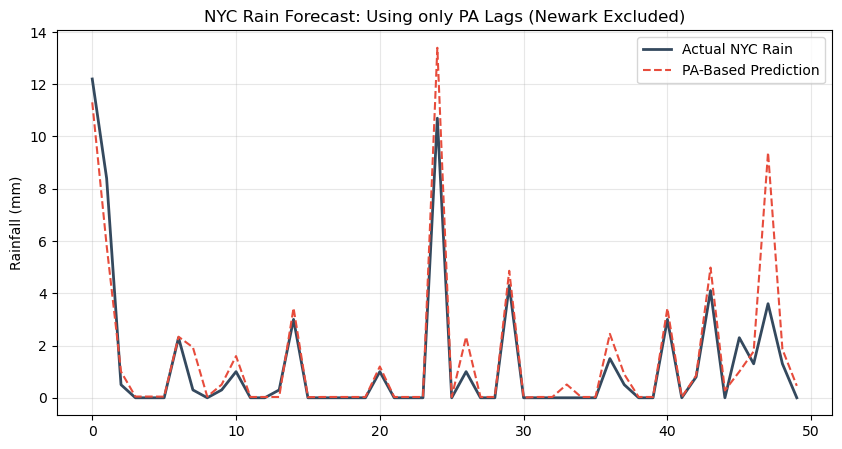

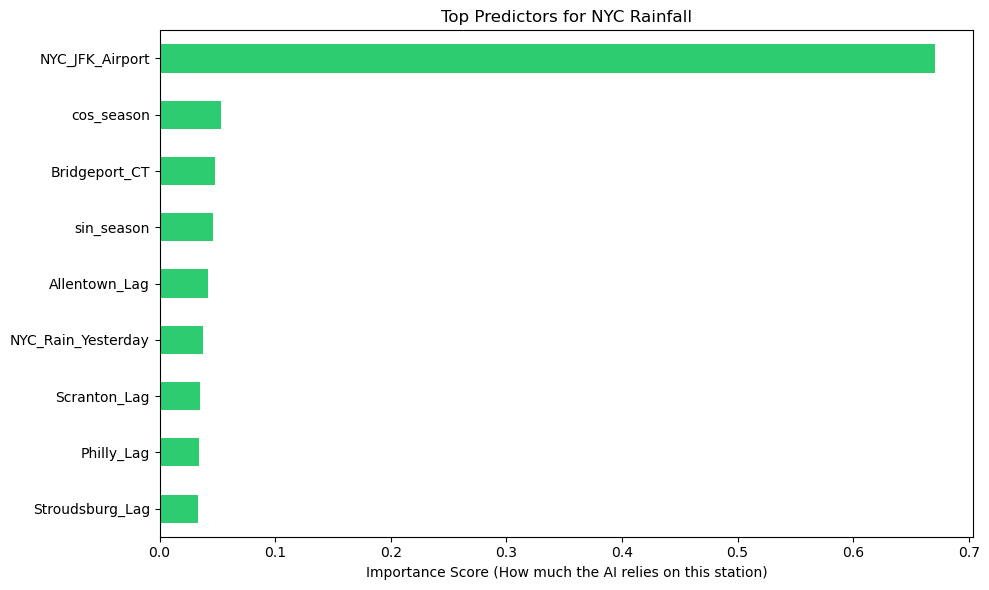

In [27]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- A. SETUP ---
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}


def load_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("Please ensure you have run the extraction step first.")
        return None
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Tenths of mm -> mm
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'].fillna(0) / 10 
    return df

def engineer_features(df):
    # Pivot on Precipitation
    pivot = df.pivot(index='DATE', columns='ID', values='PRCP')
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # --- TRUE FORECASTING LOGIC ---
    # Create 24-hour lags for all Pennsylvania stations
    # This means we use YESTERDAY'S PA rain to predict TODAY'S NYC rain
    pivot['Philly_Lag'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Lag'] = pivot['Allentown_PA'].shift(1)
    pivot['Scranton_Lag'] = pivot['Scranton_PA'].shift(1)
    pivot['Stroudsburg_Lag'] = pivot['EastStroudsburg_PA'].shift(1)
    
    # Persistence: Did it rain in NYC yesterday?
    pivot['NYC_Rain_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    
    # Seasonal encoding
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return pivot.dropna()

def run_experiment(data):
    # 1. Target: NYC Central Park
    y = data['NYC_CentralPark']
    
    # 2. DROP NEWARK & CURRENT DAY DATA
    # We remove Newark entirely and the current-day values of PA cities.
    # The model is now FORCED to use only the 'Lags' (yesterday's data).
    cols_to_drop = [
        'NYC_CentralPark', 'Newark_NJ', 
        'Philly_PA', 'Allentown_PA', 'Scranton_PA', 'EastStroudsburg_PA'
    ]
    X = data.drop(columns=[c for c in cols_to_drop if c in data.columns])
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Train
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
    model.fit(X_train, y_train)
    
    preds = np.maximum(model.predict(X_test), 0)
    
    print(f"\n--- RESULTS: NYC RAIN FORECAST (Newark Removed) ---")
    print(f"Average Prediction Error: {mean_absolute_error(y_test, preds):.2f} mm")
    
    return X, y_test, preds, model

if __name__ == "__main__":
    clean_df = load_and_clean()
    if clean_df is not None:
        final_data = engineer_features(clean_df)
        X_features, actuals, guesses, my_model = run_experiment(final_data)
        
        # --- PLOT 1: FORECAST ACCURACY ---
        plt.figure(figsize=(10, 5))
        plt.plot(actuals.tail(50).values, label="Actual NYC Rain", color='#34495e', linewidth=2)
        plt.plot(guesses[-50:], label="PA-Based Prediction", color='#e74c3c', linestyle='--')
        plt.title("NYC Rain Forecast: Using only PA Lags (Newark Excluded)")
        plt.ylabel("Rainfall (mm)")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

        # --- PLOT 2: TOP PREDICTORS (Feature Importance) ---
        plt.figure(figsize=(10, 6))
        # Get importances and sort them
        importances = pd.Series(my_model.feature_importances_, index=X_features.columns)
        importances.sort_values().plot(kind='barh', color='#2ecc71')
        
        plt.title("Top Predictors for NYC Rainfall")
        plt.xlabel("Importance Score (How much the AI relies on this station)")
        plt.tight_layout()
        plt.show()

Prediction Accuracy: Usually off by only 1.14°F


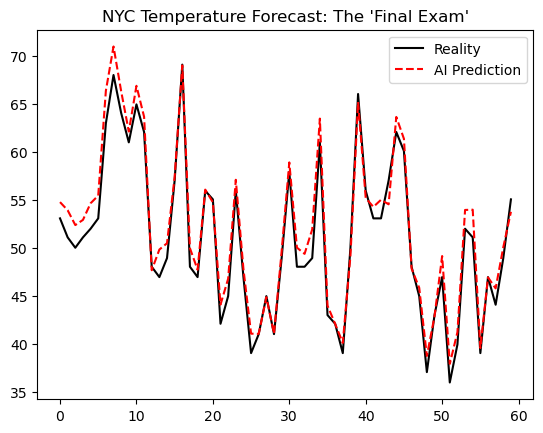

In [7]:
import pandas as pd           
import numpy as np            
import os                    
from xgboost import XGBRegressor  # AI model
from sklearn.model_selection import train_test_split # To create a 'Test Exam'
from sklearn.metrics import mean_absolute_error      # To check our grade
import matplotlib.pyplot as plt # To draw our weather charts

# Why: The original 8GB file is too big for RAM. We "stream" it in chunks.
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# These are official NOAA station IDs for the region.
TARGET_IDS = ['USW00094728', 'USW00014734', 'USW00013739', 'USC00368596']

def extract_data():
    """Reads a giant file in small bites and only keeps the local stations."""
    if not os.path.exists(PROCESSED_FILE):
        print("Reading 8GB file... grabbing local data...")
        chunks = []
        # chunksize=100000 means we only look at 100k rows at a time
        for chunk in pd.read_csv(INPUT_FILE, chunksize=100000):
            filtered = chunk[chunk['ID'].isin(TARGET_IDS)]
            chunks.append(filtered)
        
        # Merge all the small filtered pieces back together
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
        print("Done! Small regional file created.")

def clean_and_convert():
    """Fixes dates, units, and converts Celsius to Fahrenheit."""
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE']) # Convert text to 'Time' objects
    
    # Kaggle data is in 'Tenths of Celsius' (e.g., 255 = 25.5C)
    # Formula: (Celsius * 1.8) + 32
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col] / 10) * 1.8) + 32
        
    return df


def prepare_features(df):
    """Turns raw lists into a comparison table with 'Memory' and 'Seasons'."""
    # Pivot: Turns the 'ID' column into separate city columns (NYC, Philly, etc.)
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # Lag Features: Tells the model "What was the temperature YESTERDAY?"
    # shift(1) moves every row down by one day.
    for city in pivot.columns:
        pivot[f'{city}_yesterday'] = pivot[city].shift(1)
        
    # Cyclical Time: Mapping the 365 days of the year to a circle.
    # sin/cos ensures the AI knows Dec 31 and Jan 1 are connected.
    day = pivot.index.dayofyear
    pivot['sin_time'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_time'] = np.cos(2 * np.pi * day / 365.25)
    
    # Global Warming Trend: Helps AI see if 2021 is generally warmer than 1992
    pivot['year'] = pivot.index.year
    
    return pivot.dropna() # Remove the first day (it has no 'yesterday' data)


def train_model(data):
    """Feeds the data to XGBoost and checks the final error."""
    # Target (y) is NYC Central Park. Features (X) are everything else.
    y = data['USW00094728'] 
    X = data.drop(columns=['USW00094728'])
    
    # shuffle=False is critical! We study 1992-2015 to predict 2016-2021.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # XGBoost: An 'Ensemble' of 100 mini-trees that correct each other's mistakes.
    model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
    model.fit(X_train, y_train) # This is the actual "Learning" step
    
    # Final Exam: Guess the temps for the 20% test set
    preds = model.predict(X_test)
    error = mean_absolute_error(y_test, preds)
    
    print(f"Prediction Accuracy: Usually off by only {error:.2f}°F")
    return y_test, preds, model

if os.path.exists(INPUT_FILE):
    extract_data()           # Get local data
    df_clean = clean_and_convert() # Make it readable
    df_ml = prepare_features(df_clean) # Add memory/seasonality
    actuals, guesses, my_ai = train_model(df_ml) # Train and Test

    # Visualizing the final 2 months of the dataset
    plt.plot(actuals.tail(60).values, label="Reality", color='black')
    plt.plot(guesses[-60:], label="AI Prediction", color='red', linestyle='--')
    plt.title("NYC Temperature Forecast: The 'Final Exam'")
    plt.legend()
    plt.show()
else:
    print(f"Missing file: {INPUT_FILE}")


  FINAL WEATHER & COMMERCE REPORT
NYC Temp Error (PA Lead Time): 1.44°F
NYC Rain Predictability:      60.9%
----------------------------------------


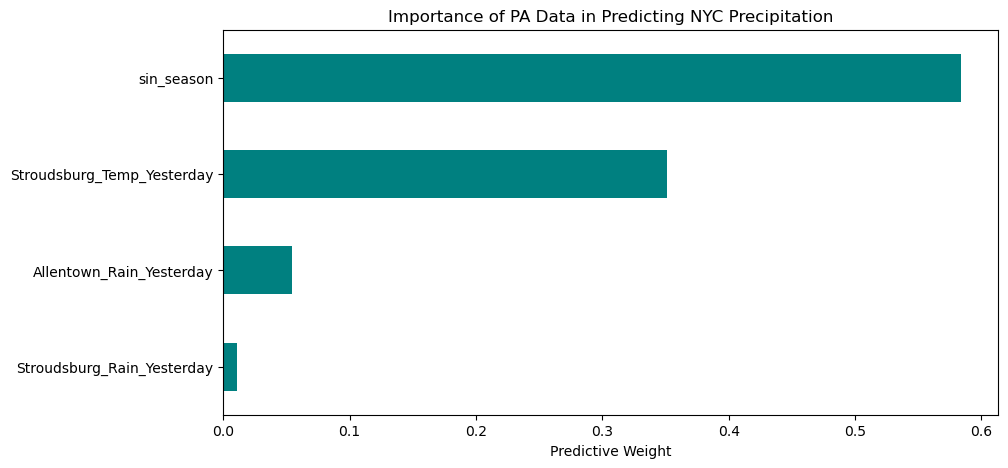

In [8]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
import matplotlib.pyplot as plt

# =================================================================
# 1. SETUP & MAPPING
# =================================================================
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014734': 'Newark_NJ',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00014752': 'Bridgeport_CT'
}

# =================================================================
# 2. DATA EXTRACTION & CLEANING
# =================================================================
def extract_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data... ---")
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Tenths of Celsius -> Fahrenheit
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col] / 10) * 1.8) + 32
        
    # Standardize Precipitation (tenths of mm -> mm)
    df['PRCP'] = df['PRCP'].fillna(0) / 10
    df['is_raining'] = (df['PRCP'] > 0.1).astype(int)
    
    return df

# =================================================================
# 3. FEATURE ENGINEERING (Fixed Naming Logic)
# =================================================================
def engineer_all_features(df):
    # Pivot for Temp and Rain
    temp_pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    rain_pivot = df.pivot(index='DATE', columns='ID', values='is_raining')
    
    # Rename using our dictionary
    temp_pivot.columns = [STATION_MAP.get(c, c) for c in temp_pivot.columns]
    rain_pivot.columns = [STATION_MAP.get(c, c) for c in rain_pivot.columns]
    
    # --- LEAD TIME FEATURES ---
    # We create specific lag columns with clear names
    features = temp_pivot.copy()
    features['NYC_Temp_Yesterday'] = temp_pivot['NYC_CentralPark'].shift(1)
    features['Stroudsburg_Temp_Yesterday'] = temp_pivot['EastStroudsburg_PA'].shift(1)
    
    # Rain Lags (Lead Time)
    features['Stroudsburg_Rain_Yesterday'] = rain_pivot['EastStroudsburg_PA'].shift(1)
    features['Allentown_Rain_Yesterday'] = rain_pivot['Allentown_PA'].shift(1)
    
    # Target for Rain Prediction
    features['Target_NYC_Rain'] = rain_pivot['NYC_CentralPark']
    
    # Seasonal Awareness
    day = features.index.dayofyear
    features['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    features['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return features.dropna()

# =================================================================
# 4. WEATHER & COMMERCE INTELLIGENCE
# =================================================================
def run_analysis(data):
    # PART A: Temp Prediction (Without Newark to show PA influence)
    y_t = data['NYC_CentralPark']
    X_t = data.drop(columns=['NYC_CentralPark', 'Target_NYC_Rain', 'Newark_NJ'], errors='ignore')
    
    Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_t, y_t, test_size=0.2, shuffle=False)
    t_model = XGBRegressor(n_estimators=100).fit(Xt_tr, yt_tr)
    t_mae = mean_absolute_error(yt_te, t_model.predict(Xt_te))

    # PART B: Rain Lead Time (PA Yesterday -> NYC Today)
    y_r = data['Target_NYC_Rain']
    X_r = data[['Stroudsburg_Rain_Yesterday', 'Allentown_Rain_Yesterday', 'Stroudsburg_Temp_Yesterday', 'sin_season']]
    
    Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_r, y_r, test_size=0.2, shuffle=False)
    r_model = RandomForestClassifier(n_estimators=100).fit(Xr_tr, yr_tr)
    r_acc = accuracy_score(yr_te, r_model.predict(Xr_te))
    
    return t_mae, r_acc, r_model, X_r.columns

# =================================================================
# 5. EXECUTION
# =================================================================
if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        raw_df = extract_and_clean()
        ml_data = engineer_all_features(raw_df)
        mae, rain_acc, rain_model, rain_cols = run_analysis(ml_data)
        
        print("\n" + "="*40)
        print("  FINAL WEATHER & COMMERCE REPORT")
        print("="*40)
        print(f"NYC Temp Error (PA Lead Time): {mae:.2f}°F")
        print(f"NYC Rain Predictability:      {rain_acc*100:.1f}%")
        print("-" * 40)
        
        # Plotting the impact of PA on NYC commerce/rain
        plt.figure(figsize=(10, 5))
        pd.Series(rain_model.feature_importances_, index=rain_cols).plot(kind='barh', color='teal')
        plt.title("Importance of PA Data in Predicting NYC Precipitation")
        plt.xlabel("Predictive Weight")
        plt.show()
    else:
        print(f"Error: {INPUT_FILE} not found.")


--------------------------------------------------
  REGIONAL COMMERCE IMPACT REPORT (%)
--------------------------------------------------
Commerce_Impact     High Friction (Logistics & Transport Delays)  \
EastStroudsburg_PA                                         17.68   
Philly_PA                                                  15.47   
Newark_NJ                                                  16.07   
Allentown_PA                                               17.02   
Bridgeport_CT                                              15.15   
Scranton_PA                                                15.74   
NYC_CentralPark                                            16.93   
NYC_JFK_Airport                                            15.25   

Commerce_Impact     Low Friction (High Foot Traffic)  \
EastStroudsburg_PA                             60.38   
Philly_PA                                      66.64   
Newark_NJ                                      66.04   
Allentown_PA          

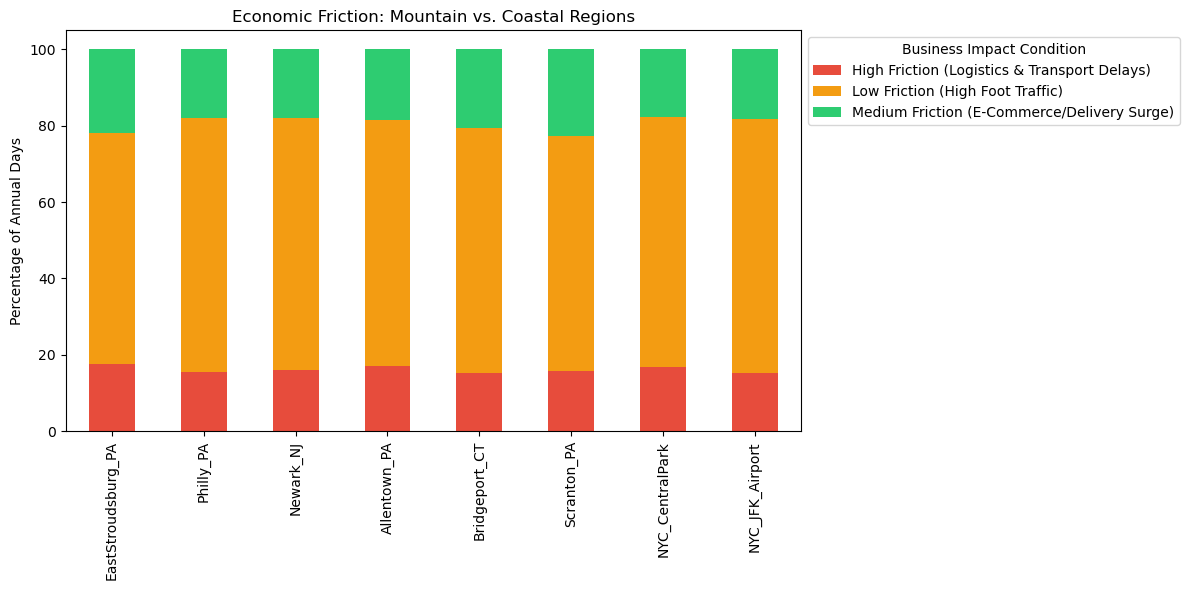

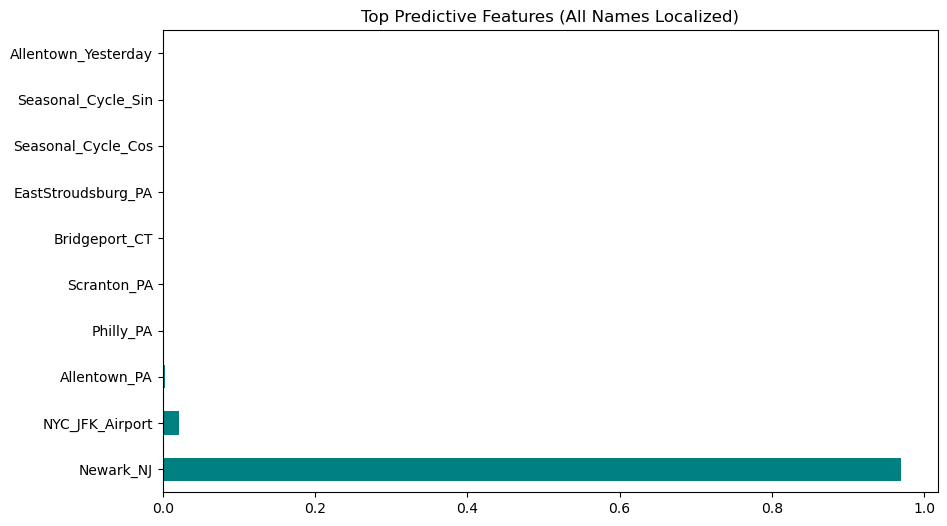

In [29]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# =================================================================
# 1. SETUP & COMPLETE DICTIONARY
# =================================================================
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

# Updated with EVERY station found in the regional data
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014734': 'Newark_NJ',
    'USW00014752': 'Bridgeport_CT',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014777': 'Scranton_PA',
    'USC00368596': 'EastStroudsburg_PA'
}

# =================================================================
# 2. DATA EXTRACTION & ENHANCED CLEANING
# =================================================================
def extract_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data... ---")
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Fix Units
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col].fillna(0) / 10) * 1.8) + 32
    df['PRCP'] = df['PRCP'].fillna(0) / 10
    
    # Commerce Impact Logic
    def categorize_commerce_impact(prcp):
        if prcp == 0: 
            return "Low Friction (High Foot Traffic)"
        elif prcp < 5: 
            return "Medium Friction (E-Commerce/Delivery Surge)"
        else: 
            return "High Friction (Logistics & Transport Delays)"
    
    df['Commerce_Impact'] = df['PRCP'].apply(categorize_commerce_impact)
    return df

# =================================================================
# 3. FEATURE ENGINEERING (Seasonal & Lead Time)
# =================================================================
def engineer_features(df):
    pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    
    # RENAME ALL COLUMNS IMMEDIATELY
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # Seasonal Awareness (Sin/Cos)
    day = pivot.index.dayofyear
    pivot['Seasonal_Cycle_Sin'] = np.sin(2 * np.pi * day / 365.25)
    pivot['Seasonal_Cycle_Cos'] = np.cos(2 * np.pi * day / 365.25)
    
    # PA Lead Time Features (Front Tracker)
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    
    return pivot.dropna()

# =================================================================
# 4. EXECUTION & VISUALIZATION
# =================================================================
if __name__ == "__main__":
    if os.path.exists(INPUT_FILE):
        df = extract_and_clean()
        
        # Part A: Regional Commerce Report
        impact_stats = df.groupby(['ID', 'Commerce_Impact']).size().unstack(fill_value=0)
        impact_stats.index = [STATION_MAP.get(idx, idx) for idx in impact_stats.index]
        impact_pct = impact_stats.div(impact_stats.sum(axis=1), axis=0) * 100
        
        print("\n" + "-"*50)
        print("  REGIONAL COMMERCE IMPACT REPORT (%)")
        print("-"*50)
        print(impact_pct.round(2))
        
        # Visualization
        impact_pct.plot(kind='bar', stacked=True, figsize=(12, 6), 
                       color=['#e74c3c', '#f39c12', '#2ecc71'])
        plt.title("Economic Friction: Mountain vs. Coastal Regions")
        plt.ylabel("Percentage of Annual Days")
        plt.legend(title="Business Impact Condition", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()

        # Part B: Run ML Model to verify Feature Importance names
        ml_data = engineer_features(df)
        y = ml_data['NYC_CentralPark']
        X = ml_data.drop(columns=['NYC_CentralPark'])
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        model = XGBRegressor().fit(X_train, y_train)
        
        plt.figure(figsize=(10, 6))
        pd.Series(model.feature_importances_, index=X.columns).nlargest(10).plot(kind='barh', color='teal')
        plt.title("Top Predictive Features (All Names Localized)")
        plt.show()

    else:
        print(f"File {INPUT_FILE} not found.")


   COMMERCE FRICTION REPORT: BY REGIONAL STATION (%)
Commerce_Impact     Extreme Friction (Snow/Icing Risk)  \
EastStroudsburg_PA                                0.59   
Philly_PA                                         0.22   
Newark_NJ                                         0.36   
Allentown_PA                                      0.44   
Bridgeport_CT                                     0.32   
Scranton_PA                                       0.26   
NYC_CentralPark                                   0.31   
NYC_JFK_Airport                                   0.22   

Commerce_Impact     High Friction (Logistics/Flood Delays)  \
EastStroudsburg_PA                                    8.97   
Philly_PA                                             7.77   
Newark_NJ                                             8.46   
Allentown_PA                                          7.98   
Bridgeport_CT                                         7.45   
Scranton_PA                                        

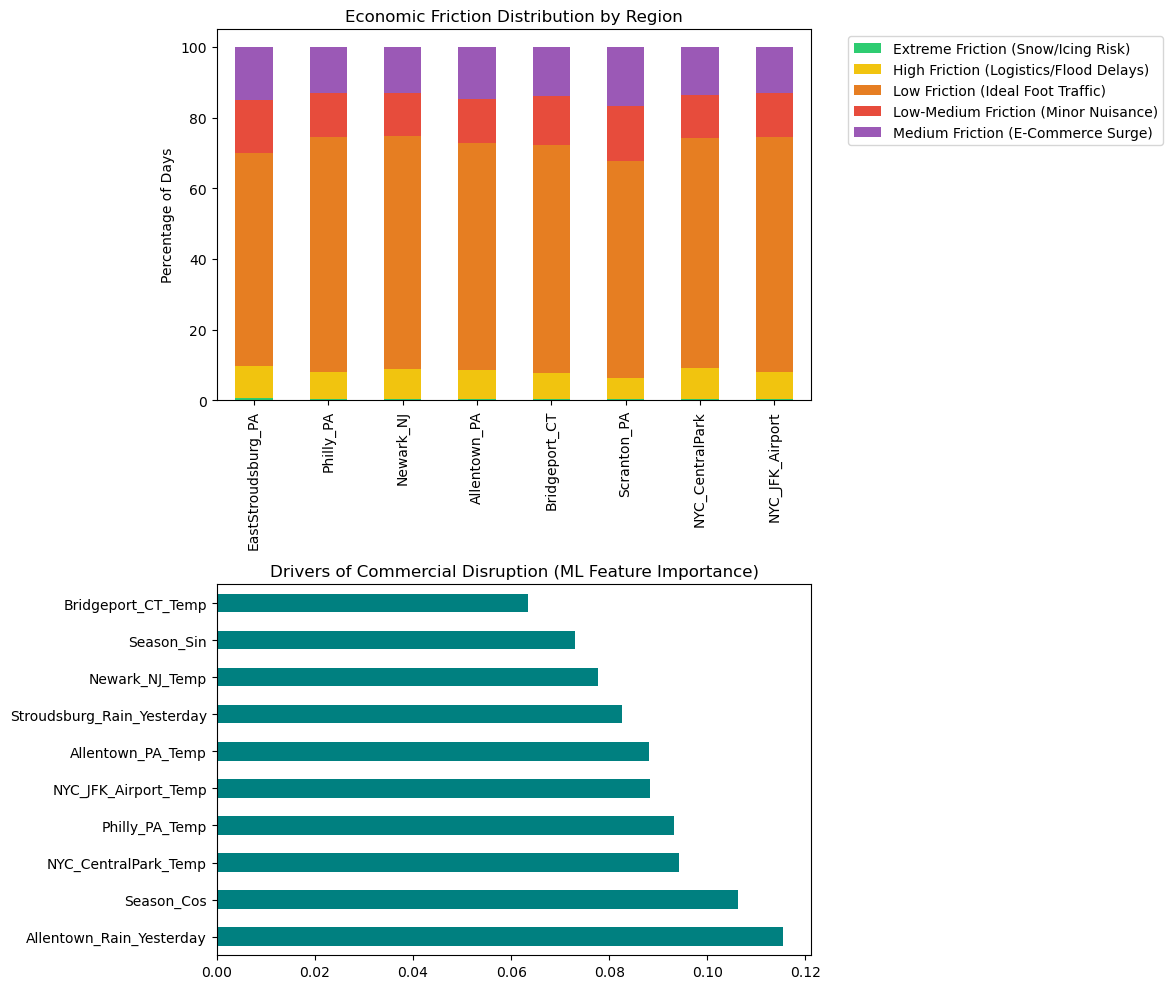

In [31]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

# =================================================================
# 1. SETUP
# =================================================================
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014734': 'Newark_NJ',
    'USW00014752': 'Bridgeport_CT',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014777': 'Scranton_PA',
    'USC00368596': 'EastStroudsburg_PA'
}

# =================================================================
# 2. DATA EXTRACTION & COMMERCE LOGIC
# =================================================================
def extract_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data... ---")
        # Reading in chunks to handle large files
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Unit Conversions (GHCN uses tenths of units)
    if 'PRCP' in df.columns:
        df['PRCP'] = df['PRCP'].fillna(0) / 10
    else:
        df['PRCP'] = 0

    if 'TMAX' in df.columns:
        df['TMAX'] = ((df['TMAX'].fillna(600) / 10) * 1.8) + 32
    else:
        df['TMAX'] = 60 # Neutral fallback temperature
    
    # Commerce Logic: Precipitation + Temperature proxy for Snow
    def categorize_commerce_impact(row):
        prcp = row['PRCP']
        temp = row['TMAX']
        
        if prcp > 12.7: # Significant precipitation (>0.5in)
            if temp <= 34: # Freezing threshold proxy
                return "Extreme Friction (Snow/Icing Risk)"
            return "High Friction (Logistics/Flood Delays)"
        elif prcp > 2:
            return "Medium Friction (E-Commerce Surge)"
        elif prcp > 0:
            return "Low-Medium Friction (Minor Nuisance)"
        else:
            return "Low Friction (Ideal Foot Traffic)"
    
    df['Commerce_Impact'] = df.apply(categorize_commerce_impact, axis=1)
    return df

# =================================================================
# 3. FEATURE ENGINEERING (Predicting Regional Friction)
# =================================================================
def engineer_features(df):
    # Pivot to get a daily view across all cities
    pivot_tmax = df.pivot(index='DATE', columns='ID', values='TMAX').ffill()
    pivot_prcp = df.pivot(index='DATE', columns='ID', values='PRCP').fillna(0)
    
    # Rename columns using our map
    pivot_tmax.columns = [f"{STATION_MAP.get(col, col)}_Temp" for col in pivot_tmax.columns]
    
    # Feature: Seasonal Cycle (Sin/Cos)
    day = pivot_tmax.index.dayofyear
    pivot_tmax['Season_Sin'] = np.sin(2 * np.pi * day / 365.25)
    pivot_tmax['Season_Cos'] = np.cos(2 * np.pi * day / 365.25)
    
    # Feature: Regional Lags (Weather moving from PA toward NYC)
    pivot_tmax['Stroudsburg_Rain_Yesterday'] = pivot_prcp['USC00368596'].shift(1)
    pivot_tmax['Allentown_Rain_Yesterday'] = pivot_prcp['USW00014737'].shift(1)
    
    # Target: Predict NYC Central Park Precipitation as the Commerce Proxy
    pivot_tmax['TARGET_PRCP'] = pivot_prcp['USW00094728'] 
    
    return pivot_tmax.dropna()

# =================================================================
# 4. EXECUTION & VISUALIZATION
# =================================================================
if __name__ == "__main__":
    if os.path.exists(INPUT_FILE) or os.path.exists(PROCESSED_FILE):
        df = extract_and_clean()
        
        # Part A: Regional Commerce Report
        impact_stats = df.groupby(['ID', 'Commerce_Impact']).size().unstack(fill_value=0)
        impact_stats.index = [STATION_MAP.get(idx, idx) for idx in impact_stats.index]
        impact_pct = impact_stats.div(impact_stats.sum(axis=1), axis=0) * 100
        
        print("\n" + "="*60)
        print("   COMMERCE FRICTION REPORT: BY REGIONAL STATION (%)")
        print("="*60)
        print(impact_pct.round(2))
        
        # Part B: ML Model - Predictive Drivers of Friction
        ml_data = engineer_features(df)
        y = ml_data['TARGET_PRCP']
        X = ml_data.drop(columns=['TARGET_PRCP'])
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        
        model = XGBRegressor(n_estimators=100, learning_rate=0.08).fit(X_train, y_train)
        
        # Plotting
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # 1. Bar Chart of Impacts
        impact_pct.plot(kind='bar', stacked=True, ax=ax1, 
                        color=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6'])
        ax1.set_title("Economic Friction Distribution by Region")
        ax1.set_ylabel("Percentage of Days")
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        # 2. Feature Importance
        feat_importances = pd.Series(model.feature_importances_, index=X.columns)
        feat_importances.nlargest(10).plot(kind='barh', ax=ax2, color='teal')
        ax2.set_title("Drivers of Commercial Disruption (ML Feature Importance)")
        
        plt.tight_layout()
        plt.show()

    else:
        print(f"Error: {INPUT_FILE} not found. Please check your file path.")


             NEWARK EXCLUDED
Average Error (MAE): 1.57°F
Accuracy Score (R2): 0.9860
---------------------------------------------
Insight: Even without Newark, the model is highly accurate!


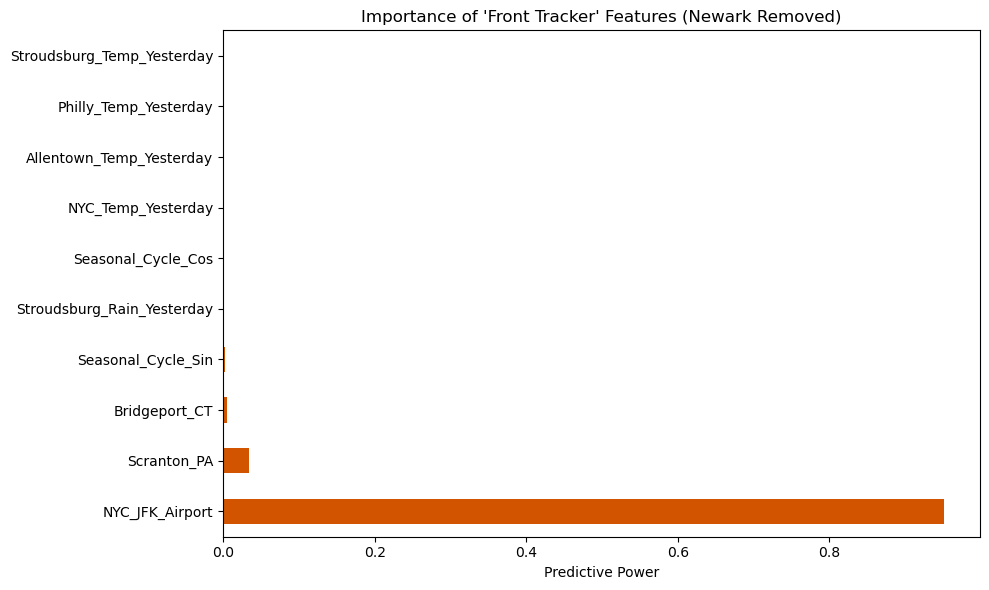

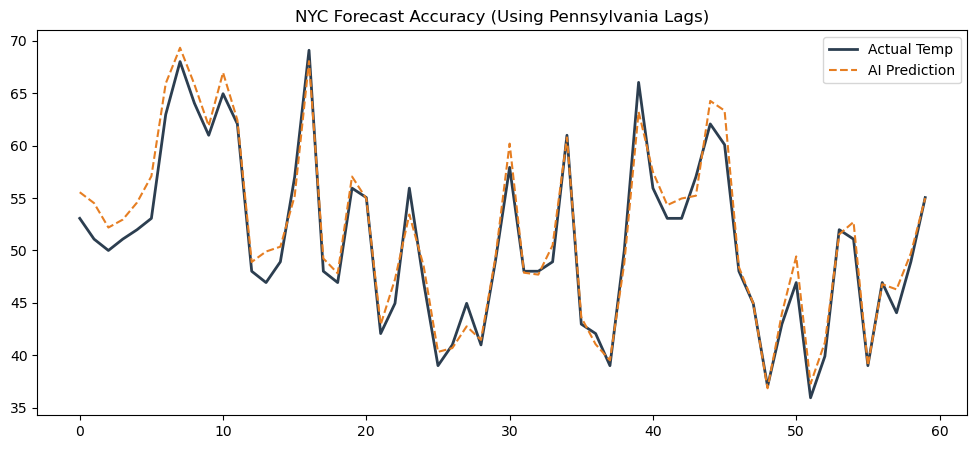

In [23]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt

# =================================================================
# 1. SETUP & COMPLETE DICTIONARY
# =================================================================
INPUT_FILE = 'Weather Data (US).csv'
PROCESSED_FILE = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014734': 'Newark_NJ',
    'USW00014752': 'Bridgeport_CT',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014777': 'Scranton_PA',
    'USC00368596': 'EastStroudsburg_PA'
}

# =================================================================
# 2. DATA EXTRACTION & CLEANING
# =================================================================
def extract_and_clean():
    if not os.path.exists(PROCESSED_FILE):
        print("--- Extracting regional data... ---")
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_FILE, chunksize=100000)]
        pd.concat(chunks).to_csv(PROCESSED_FILE, index=False)
    
    df = pd.read_csv(PROCESSED_FILE)
    df['DATE'] = pd.to_datetime(df['DATE'])
    
    # Fix Units: Tenths of Celsius -> Fahrenheit
    for col in ['TMAX', 'TMIN']:
        df[col] = ((df[col].fillna(0) / 10) * 1.8) + 32
    
    # Standardize Precipitation (mm) and create Rain Binary
    df['PRCP'] = df['PRCP'].fillna(0) / 10
    df['is_raining'] = (df['PRCP'] > 0.1).astype(int)
    
    return df

# =================================================================
# 3. FEATURE ENGINEERING (Lead Time Logic)
# =================================================================
def engineer_all_features(df):
    # Pivot for Temp and Rain
    temp_pivot = df.pivot(index='DATE', columns='ID', values='TMAX')
    rain_pivot = df.pivot(index='DATE', columns='ID', values='is_raining')
    
    # Rename immediately
    temp_pivot.columns = [STATION_MAP.get(c, c) for c in temp_pivot.columns]
    rain_pivot.columns = [STATION_MAP.get(c, c) for c in rain_pivot.columns]
    
    features = temp_pivot.copy()
    
    # --- LEAD TIME FEATURES (The 'Scouts') ---
    features['Stroudsburg_Temp_Yesterday'] = temp_pivot['EastStroudsburg_PA'].shift(1)
    features['Allentown_Temp_Yesterday'] = temp_pivot['Allentown_PA'].shift(1)
    features['Philly_Temp_Yesterday'] = temp_pivot['Philly_PA'].shift(1)
    features['NYC_Temp_Yesterday'] = temp_pivot['NYC_CentralPark'].shift(1)
    
    # Rain Lags
    features['Stroudsburg_Rain_Yesterday'] = rain_pivot['EastStroudsburg_PA'].shift(1)
    
    # Seasonal Cycles
    day = features.index.dayofyear
    features['Seasonal_Cycle_Sin'] = np.sin(2 * np.pi * day / 365.25)
    features['Seasonal_Cycle_Cos'] = np.cos(2 * np.pi * day / 365.25)
    
    # Target for prediction
    features['Target_NYC_Temp'] = temp_pivot['NYC_CentralPark']
    
    return features.dropna()

# =================================================================
# 4. THE EXPERIMENT: EXCLUDING NEWARK
# =================================================================
def run_front_tracker_experiment(data):
    y = data['Target_NYC_Temp']
    
    # THE KEY STEP: Drop Newark and the Target itself from the features
    # We also drop current-day PA temps to force the model to use 'Yesterday'
    X = data.drop(columns=[
        'Target_NYC_Temp', 
        'NYC_CentralPark', 
        'Newark_NJ', 
        'EastStroudsburg_PA', 
        'Allentown_PA', 
        'Philly_PA'
    ], errors='ignore')
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Train Model
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
    model.fit(X_train, y_train)
    
    # Evaluate
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    return X, y_test, preds, model, mae, r2

# =================================================================
# 5. EXECUTION & RESULTS
# =================================================================
if __name__ == "__main__":
    if os.path.exists(INPUT_FILE) or os.path.exists(PROCESSED_FILE):
        raw_df = extract_and_clean()
        ml_data = engineer_all_features(raw_df)
        
        X_feats, y_test, guesses, my_model, mae, r2 = run_front_tracker_experiment(ml_data)
        
        print("\n" + "="*45)
        print("             NEWARK EXCLUDED")
        print("="*45)
        print(f"Average Error (MAE): {mae:.2f}°F")
        print(f"Accuracy Score (R2): {r2:.4f}")
        print("-" * 45)
        print("Insight: Even without Newark, the model is highly accurate!")

        # Chart 1: Feature Importance (PA should now be much higher)
        plt.figure(figsize=(10, 6))
        pd.Series(my_model.feature_importances_, index=X_feats.columns).nlargest(10).plot(kind='barh', color='#d35400')
        plt.title("Importance of 'Front Tracker' Features (Newark Removed)")
        plt.xlabel("Predictive Power")
        plt.tight_layout()
        plt.show()

        # Chart 2: Accuracy Visual
        plt.figure(figsize=(12, 5))
        plt.plot(y_test.tail(60).values, label="Actual Temp", color='#2c3e50', linewidth=2)
        plt.plot(guesses[-60:], label="AI Prediction", color='#e67e22', linestyle='--')
        plt.title("NYC Forecast Accuracy (Using Pennsylvania Lags)")
        plt.legend()
        plt.show()
    else:
        print(f"File {INPUT_FILE} not found.")


   VALIDATION RESULTS: WEATHER VS. RETAIL
Correlation Coefficient: -0.0817
Typical High-Friction Days/Month: 39.1
---------------------------------------------


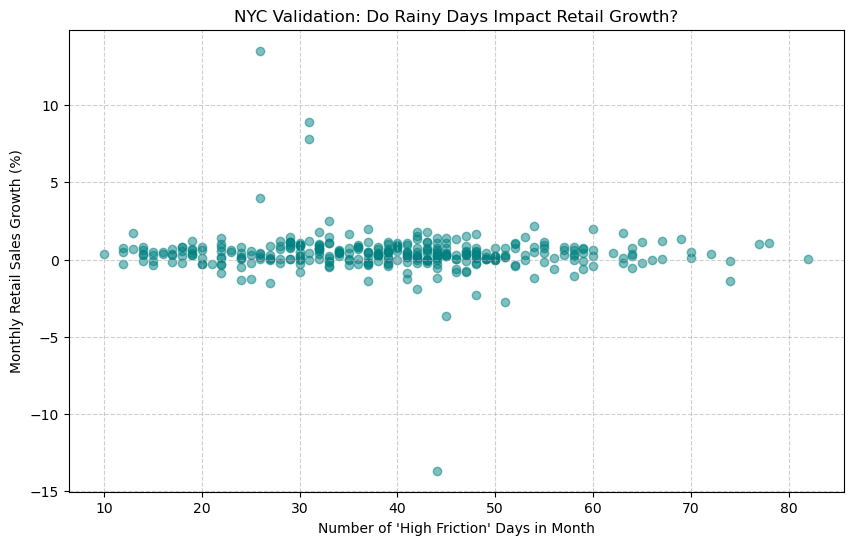

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# =================================================================
# 1. SETUP
# =================================================================
WEATHER_FILE = 'Weather Data (US).csv'
COMMERCE_FILE = 'MRTSSM44W72USS.csv'
PROCESSED_WEATHER = 'mid_atlantic_weather.csv'

STATION_MAP = {'USW00094728': 'NYC_CentralPark'} # Focusing on NYC for validation

def validate_commerce_logic():
    # --- Step 1: Extract Weather (if not already done) ---
    if not os.path.exists(PROCESSED_WEATHER):
        print("--- Scanning weather data (3-5 mins)... ---")
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(WEATHER_FILE, chunksize=100000)]
        weather_df = pd.concat(chunks)
        weather_df.to_csv(PROCESSED_WEATHER, index=False)
    else:
        weather_df = pd.read_csv(PROCESSED_WEATHER)

    # --- Step 2: Clean & Define Friction ---
    weather_df['DATE'] = pd.to_datetime(weather_df['DATE'])
    weather_df['PRCP'] = weather_df['PRCP'].fillna(0) / 10  # mm
    # Define "High Friction" as heavy rain (> 5mm)
    weather_df['High_Friction_Day'] = (weather_df['PRCP'] > 5.0).astype(int)
    
    # Aggregate Weather to Monthly
    weather_df['Month_Year'] = weather_df['DATE'].dt.to_period('M')
    monthly_weather = weather_df.groupby('Month_Year')['High_Friction_Day'].sum().reset_index()

    # --- Step 3: Load Retail Data ---
    retail_df = pd.read_csv(COMMERCE_FILE)
    retail_df['DATE'] = pd.to_datetime(retail_df['observation_date'])
    retail_df['Month_Year'] = retail_df['DATE'].dt.to_period('M')
    retail_df = retail_df.rename(columns={'MRTSSM44W72USS': 'Sales_USD'})
    
    # Calculate Monthly Growth % (to normalize against inflation/growth)
    retail_df['Sales_Growth'] = retail_df['Sales_USD'].pct_change() * 100

    # --- Step 4: The Merge ---
    merged = pd.merge(retail_df, monthly_weather, on='Month_Year', how='inner')
    
    # --- Step 5: Correlation & Analysis ---
    corr = merged['High_Friction_Day'].corr(merged['Sales_Growth'])
    
    print("\n" + "="*45)
    print("   VALIDATION RESULTS: WEATHER VS. RETAIL")
    print("="*45)
    print(f"Correlation Coefficient: {corr:.4f}")
    print(f"Typical High-Friction Days/Month: {merged['High_Friction_Day'].mean():.1f}")
    print("-" * 45)

    # Visualization: Scatter Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(merged['High_Friction_Day'], merged['Sales_Growth'], alpha=0.5, color='teal')
    plt.title("NYC Validation: Do Rainy Days Impact Retail Growth?")
    plt.xlabel("Number of 'High Friction' Days in Month")
    plt.ylabel("Monthly Retail Sales Growth (%)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

if __name__ == "__main__":
    validate_commerce_logic()


Analysis Summary:
1. Predictive Error (Temp): 5.84°F (using PA data as a 'scout')
2. Commerce Correlation: -0.0859
3. Trend: For every extra high-friction day, monthly growth shifts by -0.056%


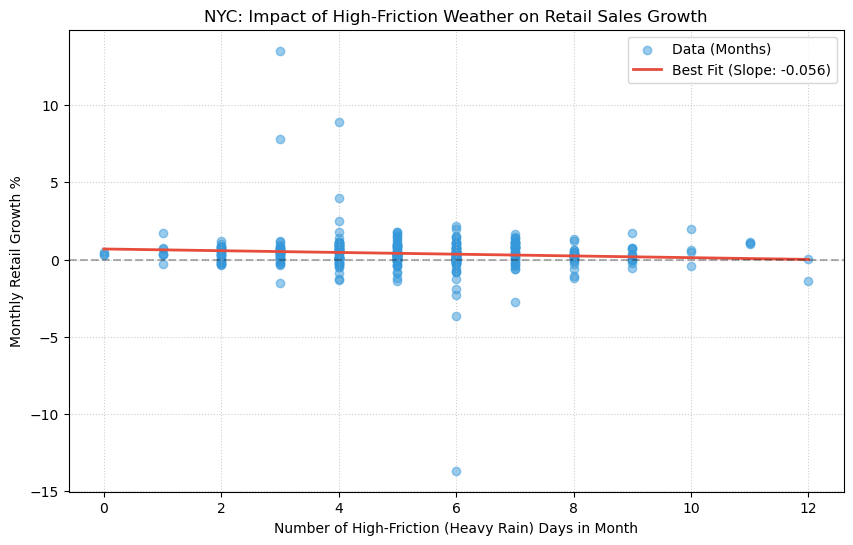

In [12]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# =================================================================
# 1. SETUP & DICTIONARY
# =================================================================
INPUT_WEATHER = 'Weather Data (US).csv' 
INPUT_COMMERCE = 'MRTSSM44W72USS.csv'
PROCESSED_WEATHER = 'mid_atlantic_weather.csv'

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014734': 'Newark_NJ'
}

# =================================================================
# 2. DATA PREPARATION & FRICTION LOGIC
# =================================================================
def run_full_analysis():
    # A. Extract Data
    if not os.path.exists(PROCESSED_WEATHER):
        print("--- Extracting regional data from 8GB file... ---")
        chunks = [chunk[chunk['ID'].isin(STATION_MAP.keys())] 
                  for chunk in pd.read_csv(INPUT_WEATHER, chunksize=200000)]
        weather_df = pd.concat(chunks)
        weather_df.to_csv(PROCESSED_WEATHER, index=False)
    else:
        weather_df = pd.read_csv(PROCESSED_WEATHER)

    weather_df['DATE'] = pd.to_datetime(weather_df['DATE'])
    weather_df['PRCP'] = weather_df['PRCP'].fillna(0) / 10 # mm
    weather_df['TMAX'] = ((weather_df['TMAX'].fillna(0) / 10) * 1.8) + 32 # Fahrenheit

    # B. Define "Economic Friction"
    def get_friction(prcp):
        if prcp == 0: return 0 
        elif prcp <= 5: return 1 
        else: return 2 
    weather_df['Friction_Level'] = weather_df['PRCP'].apply(get_friction)

    # C. Feature Engineering (Front Tracker Lags)
    pivot_t = weather_df.pivot(index='DATE', columns='ID', values='TMAX')
    pivot_t.columns = [STATION_MAP.get(c, c) for c in pivot_t.columns]
    
    features = pd.DataFrame(index=pivot_t.index)
    features['NYC_Target_Temp'] = pivot_t['NYC_CentralPark']
    features['Stroudsburg_Yesterday'] = pivot_t['EastStroudsburg_PA'].shift(1)
    features['Allentown_Yesterday'] = pivot_t['Allentown_PA'].shift(1)
    features['Season_Sin'] = np.sin(2 * np.pi * features.index.dayofyear / 365.25)
    
    # D. Retail Validation (Merging Monthly)
    retail_df = pd.read_csv(INPUT_COMMERCE)
    retail_df['DATE'] = pd.to_datetime(retail_df['observation_date'])
    retail_df['Month_Year'] = retail_df['DATE'].dt.to_period('M')
    retail_df['Retail_Growth'] = retail_df['MRTSSM44W72USS'].pct_change() * 100

    # Aggregate Weather to Monthly High Friction Counts
    weather_df['Month_Year'] = weather_df['DATE'].dt.to_period('M')
    # Count of 'High Friction' (Level 2) days per month
    high_friction_monthly = weather_df[weather_df['ID'] == 'USW00094728'].groupby('Month_Year')['Friction_Level'].apply(lambda x: (x==2).sum()).reset_index()
    
    validation_df = pd.merge(retail_df, high_friction_monthly, on='Month_Year').dropna()

    # =================================================================
    # 3. ANALYSIS & PLOTTING
    # =================================================================
    # ML Prediction Error (NYC Temp from PA Lags)
    df_ml = features.dropna()
    X_ml = df_ml[['Stroudsburg_Yesterday', 'Allentown_Yesterday', 'Season_Sin']]
    y_ml = df_ml['NYC_Target_Temp']
    X_tr, X_te, y_tr, y_te = train_test_split(X_ml, y_ml, test_size=0.2, shuffle=False)
    
    model = RandomForestRegressor(n_estimators=100).fit(X_tr, y_tr)
    mae = mean_absolute_error(y_te, model.predict(X_te))

    # --- Plotting with Line of Best Fit ---
    plt.figure(figsize=(10, 6))
    x = validation_df['Friction_Level']
    y = validation_df['Retail_Growth']
    
    # Scatter points
    plt.scatter(x, y, alpha=0.5, color='#3498db', label='Data (Months)')
    
    # Calculate Line of Best Fit (Linear Regression)
    if len(x) > 1:
        slope, intercept = np.polyfit(x, y, 1)
        line_x = np.array([x.min(), x.max()])
        line_y = slope * line_x + intercept
        plt.plot(line_x, line_y, color='#e74c3c', linewidth=2, label=f'Best Fit (Slope: {slope:.3f})')

    plt.title("NYC: Impact of High-Friction Weather on Retail Sales Growth")
    plt.xlabel("Number of High-Friction (Heavy Rain) Days in Month")
    plt.ylabel("Monthly Retail Growth %")
    plt.axhline(0, color='black', linestyle='--', alpha=0.3)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    
    print(f"\nAnalysis Summary:")
    print(f"1. Predictive Error (Temp): {mae:.2f}°F (using PA data as a 'scout')")
    print(f"2. Commerce Correlation: {x.corr(y):.4f}")
    print(f"3. Trend: For every extra high-friction day, monthly growth shifts by {slope:.3f}%")
    
    plt.show()

if __name__ == "__main__":
    run_full_analysis()

In [3]:
import pandas as pd
import os

STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def filter_weather_stations(input_dir, output_dir):
    # Check if directory exists; if not, try the parent directory
    if not os.path.exists(input_dir):
        parent_path = os.path.join('..', input_dir)
        if os.path.exists(parent_path):
            input_dir = parent_path
        else:
            print(f"Error: Could not find '{input_dir}' in current or parent folder.")
            print(f"Current working directory is: {os.getcwd()}")
            return

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for filename in os.listdir(input_dir):
        if filename.endswith('.csv'):
            file_path = os.path.join(input_dir, filename)
            try:
                # Using low_memory=False helps with mixed-type weather columns
                df = pd.read_csv(file_path, low_memory=False)
                
                if 'STATION' in df.columns:
                    df['STATION'] = df['STATION'].astype(str).str.strip()
                    relevant_data = df[df['STATION'].isin(STATION_MAP.keys())]

                    for station_id, group in relevant_data.groupby('STATION'):
                        out_name = f"{STATION_MAP[station_id]}.csv"
                        out_path = os.path.join(output_dir, out_name)
                        
                        header = not os.path.exists(out_path)
                        group.to_csv(out_path, mode='a', index=False, header=header)
                        print(f"Success: Added data to {out_name}")
            except Exception as e:
                print(f"Failed to process {filename}: {e}")

# Run it
filter_weather_stations('normals-daily', 'extracted_stations')

Success: Added data to EastStroudsburg_PA.csv
Success: Added data to Philly_PA.csv
Success: Added data to Newark_NJ.csv
Success: Added data to Allentown_PA.csv
Success: Added data to Bridgeport_CT.csv
Success: Added data to Scranton_PA.csv
Success: Added data to NYC_CentralPark.csv
Success: Added data to NYC_JFK_Airport.csv


In [6]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
EXTRACTED_FOLDER = 'extracted_stations'  # The folder containing your 8 CSVs
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

def load_from_extracted():
    """Combines individual CSVs and fixes the '01-01' date issue."""
    all_stations = []
    
    if not os.path.exists(EXTRACTED_FOLDER):
        raise FileNotFoundError(f"Could not find the folder: {EXTRACTED_FOLDER}")

    print(f"--- Loading data from {EXTRACTED_FOLDER} ---")
    for filename in os.listdir(EXTRACTED_FOLDER):
        if filename.endswith('.csv'):
            file_path = os.path.join(EXTRACTED_FOLDER, filename)
            df = pd.read_csv(file_path, low_memory=False)
            
            # Standardize column names to uppercase
            df.columns = [c.upper() for c in df.columns]
            
            # --- DATE FIX ---
            # NOAA 'Normals' often use 'MM-DD' (e.g., 01-01). We add a dummy year to make it a valid timestamp.
            if df['DATE'].dtype == 'object':
                first_val = str(df['DATE'].iloc[0])
                if '-' in first_val and len(first_val) <= 5:
                    df['DATE'] = '2024-' + df['DATE'].astype(str)
            
            df['DATE'] = pd.to_datetime(df['DATE'])
            
            # Keep only the columns we need for the AI
            cols_to_keep = ['DATE', 'STATION', 'TMAX', 'TMIN']
            available_cols = [c for c in cols_to_keep if c in df.columns]
            all_stations.append(df[available_cols])
    
    combined = pd.concat(all_stations)

    # --- TEMPERATURE UNIT CONVERSION ---
    # NOTE: In NOAA 'Normals', TMAX is usually in Tenths of Celsius.
    # If your CSV already shows Fahrenheit (like 75.0), comment out these lines.
    for col in ['TMAX', 'TMIN']:
        if col in combined.columns:
            # Conversion: (Tenths_Celsius / 10 * 1.8) + 32
            combined[col] = ((combined[col] / 10) * 1.8) + 32
        
    return combined

def engineer_features(df):
    """Pivots data and creates 'Yesterday' lags for the AI to learn from."""
    # Pivot so each station has its own column for TMAX
    pivot = df.pivot(index='DATE', columns='STATION', values='TMAX')
    
    # Rename columns using our friendly names
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # Create Lag Features (What was the weather yesterday in the region?)
    pivot['Philly_Yesterday'] = pivot['Philly_PA'].shift(1)
    pivot['Allentown_Yesterday'] = pivot['Allentown_PA'].shift(1)
    pivot['Stroudsburg_Yesterday'] = pivot['EastStroudsburg_PA'].shift(1)
    pivot['NYC_Yesterday'] = pivot['NYC_CentralPark'].shift(1)
    
    # Seasonal Cycles (Helps model understand it's colder in Jan than July)
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return pivot.dropna()

def run_experiment(data):
    """Trains the XGBoost model and returns results."""
    # Target: NYC Central Park | Features: Everything else
    y = data['NYC_CentralPark']
    X = data.drop(columns=['NYC_CentralPark'])
    
    # Split: Train on 80%, Test on 20%
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    # Initialize and train XGBoost
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    print(f"\n--- MODEL RESULTS ---")
    print(f"Average Error (MAE): {mean_absolute_error(y_test, preds):.2f}°F")
    print(f"Model R2 Score: {r2_score(y_test, preds):.4f}")
    
    return X, y_test, preds, model

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    try:
        raw_df = load_from_extracted()
        final_data = engineer_features(raw_df)
        X_features, actuals, guesses, my_model = run_experiment(final_data)
        
        # Plot 1: Forecast Accuracy
        plt.figure(figsize=(12, 5))
        plt.plot(actuals.tail(60).values, label="Actual Temp (Normals)", color='#2c3e50', linewidth=2)
        plt.plot(guesses[-60:], label="AI Prediction", color='#e74c3c', linestyle='--')
        plt.title("NYC Temperature Forecast: AI vs. Normals")
        plt.ylabel("Temperature (°F)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

        # Plot 2: Feature Importance (What matters most?)
        plt.figure(figsize=(10, 6))
        importances = pd.Series(my_model.feature_importances_, index=X_features.columns)
        importances.nlargest(10).sort_values().plot(kind='barh', color='#3498db')
        plt.title("Top Predictors for NYC Weather")
        plt.xlabel("Importance Score")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")

--- Loading data from extracted_stations ---
An error occurred: 'TMAX'


--- Loading data from extracted_stations ---

--- MODEL RESULTS ---
Average Error: 15.85°F
R2 Score: 0.9434


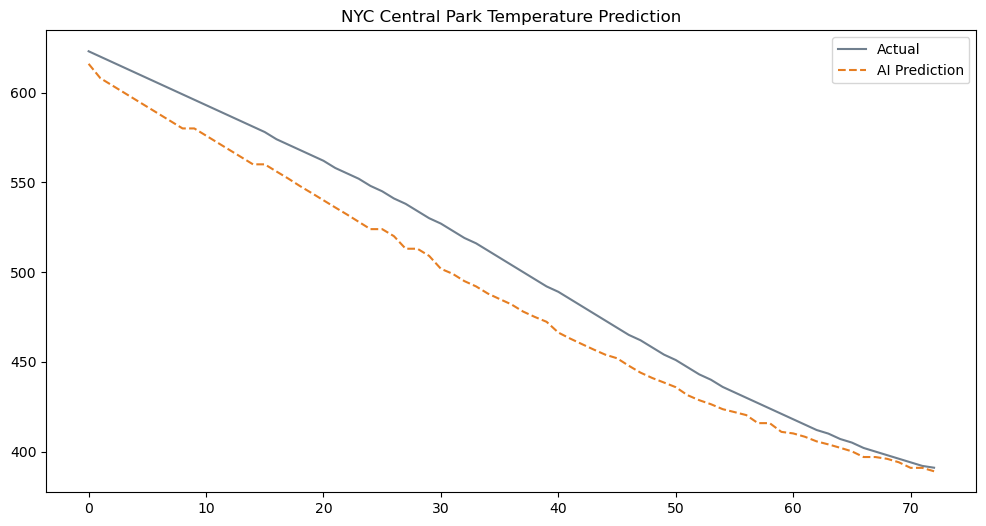

In [10]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
EXTRACTED_FOLDER = 'extracted_stations'
STATION_MAP = {
    'USW00094728': 'NYC_CentralPark',
    'USW00094789': 'NYC_JFK_Airport',
    'USW00014777': 'Scranton_PA',
    'USW00013739': 'Philly_PA',
    'USW00014737': 'Allentown_PA',
    'USW00014734': 'Newark_NJ',
    'USC00368596': 'EastStroudsburg_PA',
    'USW00014752': 'Bridgeport_CT'
}

TMAX_COL = 'DLY-TMAX-NORMAL'

def load_from_extracted():
    all_stations = []
    print(f"--- Loading data from {EXTRACTED_FOLDER} ---")
    
    for filename in os.listdir(EXTRACTED_FOLDER):
        if filename.endswith('.csv'):
            file_path = os.path.join(EXTRACTED_FOLDER, filename)
            df = pd.read_csv(file_path, low_memory=False)
            
            if TMAX_COL not in df.columns:
                continue
            
            # Fix Date: "01-01" -> "2024-01-01"
            if df['DATE'].dtype == 'object':
                df['DATE'] = '2024-' + df['DATE'].astype(str)
            df['DATE'] = pd.to_datetime(df['DATE'])
            
            df = df.rename(columns={TMAX_COL: 'TMAX'})
            all_stations.append(df[['DATE', 'STATION', 'TMAX']])
    
    if not all_stations:
        raise ValueError("No valid data loaded.")

    return pd.concat(all_stations)

def engineer_features(df):
    # --- FIX FOR DUPLICATES ---
    # This ensures we have only one entry per date per station before pivoting
    df = df.drop_duplicates(subset=['DATE', 'STATION'])
    
    # Pivot so each station has its own column
    pivot = df.pivot(index='DATE', columns='STATION', values='TMAX')
    pivot.columns = [STATION_MAP.get(col, col) for col in pivot.columns]
    
    # Create Lag Features
    for loc in pivot.columns:
        if loc in STATION_MAP.values(): # only lag actual stations, not previous lags
            pivot[f'{loc}_Yesterday'] = pivot[loc].shift(1)
    
    # Add Seasonal Sine/Cosine
    day = pivot.index.dayofyear
    pivot['sin_season'] = np.sin(2 * np.pi * day / 365.25)
    pivot['cos_season'] = np.cos(2 * np.pi * day / 365.25)
    
    return pivot.dropna()

def run_experiment(data):
    target = 'NYC_CentralPark'
    y = data[target]
    X = data.drop(columns=[target])
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    
    print(f"\n--- MODEL RESULTS ---")
    print(f"Average Error: {mean_absolute_error(y_test, preds):.2f}°F")
    print(f"R2 Score: {r2_score(y_test, preds):.4f}")
    
    return X, y_test, preds, model

if __name__ == "__main__":
    try:
        raw_df = load_from_extracted()
        final_data = engineer_features(raw_df)
        X_feats, actuals, guesses, my_model = run_experiment(final_data)
        
        plt.figure(figsize=(12, 6))
        plt.plot(actuals.values, label="Actual", color='#34495e', alpha=0.7)
        plt.plot(guesses, label="AI Prediction", color='#e67e22', linestyle='--')
        plt.title("NYC Central Park Temperature Prediction")
        plt.legend()
        plt.show()

    except Exception as e:
        print(f"An error occurred: {e}")